In [1]:
import numpy as np

In [2]:
#field elements hardcoded
field_elements=np.array([
    [0,0,1],
    [0,1,0],
    [1,0,0],
    [0,1,1],
    [1,1,0],
    [1,1,1],
    [1,0,1]
    ])

# field_elements=np.array([
#     [1,0,1],
#     [1,1,1],
#     [1,1,0],
#     [0,1,1],
#     [1,0,0],
#     [0,1,0],
#     [0,0,1]
#     ])

field_element_0=np.array([0,0,0])

def get_s_1(r):
    temp=field_element_0
    for i in range(7):
        if r[6-i]==1:
            temp=np.bitwise_xor(temp, field_elements[i])
    return temp

def get_s_3(r):
    temp=field_element_0
    for i in range(7):
        if r[6-i]==1:
            temp=np.bitwise_xor(temp, field_elements[(i*3)%7])
    return temp



In [3]:
#testing that we get 0 syndrome for correct codeword

exampe_correct_codeword=np.array([1,1,1,1,1,1,1])

syndromes_correct= get_s_1(exampe_correct_codeword), get_s_3(exampe_correct_codeword)

print(syndromes_correct)



(array([0, 0, 0]), array([0, 0, 0]))


In [4]:
#now we seek to test that 1 error is filterable by s_1^3 = s_3, and that the output is the correct index
exampe_1error_codeword=np.array([1,1,1,1,1,0,1])
syndromes_1error= get_s_1(exampe_1error_codeword), get_s_3(exampe_1error_codeword)

def power_3(r):
    for i in range(7):
        if np.array_equal(r,field_elements[i]):
            return field_elements[(i*3)%7]
s_1_power3=power_3(syndromes_1error[0])

print(s_1_power3,syndromes_1error[1])


[0 1 1] [0 1 1]


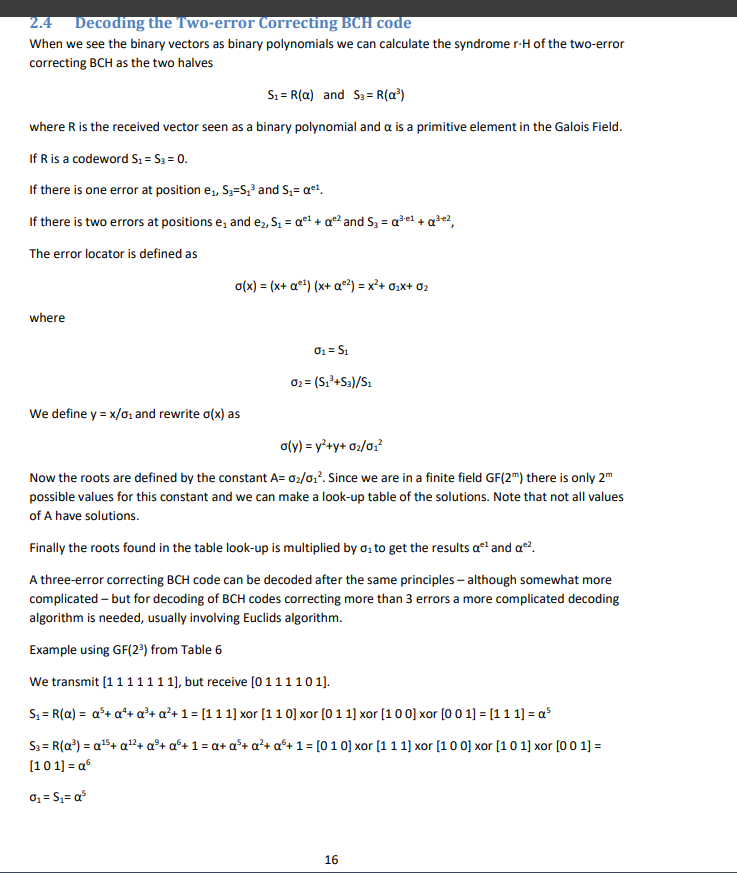

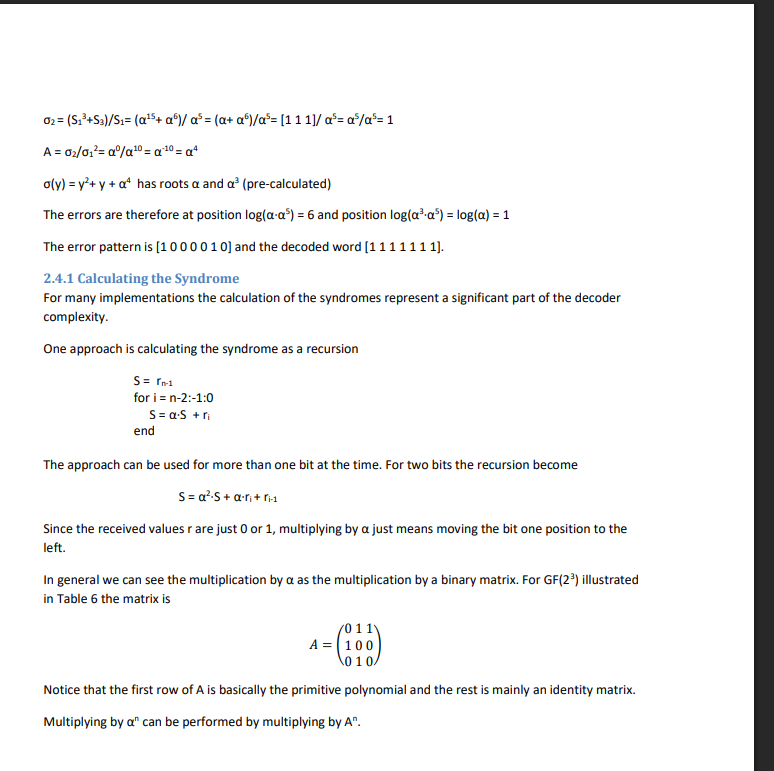

In [5]:
#simply trying to implement the pictues above, with the exact example to make sure its functions

exampe_2error_codeword=np.array([0,1,1,1,1,0,1])

syndromes_2error= get_s_1(exampe_2error_codeword), get_s_3(exampe_2error_codeword)
print(syndromes_2error)
print()
s_1_power3=power_3(syndromes_2error[0])

def elem_index(r):
    for i in range(7):
        if np.array_equal(r,field_elements[i]):
            return i
        
def get_big_sigma_2(syndrome_tuple):
    top=np.bitwise_xor(power_3(syndrome_tuple[0]), syndrome_tuple[1])
    top_index=elem_index(top)
    bottom_index=elem_index(syndrome_tuple[0])
    final_index=(top_index-bottom_index)%7
    return field_elements[final_index]

sigma_1=syndromes_2error[0]
sigma_2=get_big_sigma_2(syndromes_2error)

print()
print(sigma_1, elem_index(sigma_1))

print()
print(sigma_2, elem_index(sigma_2))


(array([1, 1, 1]), array([1, 0, 1]))


[1 1 1] 5

[0 0 1] 0


In [6]:
#next part with the sigmas established
def power_2(r):
    for i in range(7):
        if np.array_equal(r,field_elements[i]):
            return field_elements[(i*2)%7]

A=elem_index(field_elements[elem_index(sigma_2)-elem_index(power_2(sigma_1))])
print(A)



4


In [7]:
#i guess this is where the table implementation should kick in
def get_roots():
    a=field_elements[A]
    roots= []
    for i in range(7):
        y=field_elements[i]
        y_squared=field_elements[(i*2)%7]
        first_calc=np.bitwise_xor(y,y_squared)
        second_calc=np.bitwise_xor(first_calc,a)
        print(second_calc)
        if np.array_equal(second_calc,field_element_0):
            roots.append((i + elem_index(sigma_1))%7)
    return roots
example_roots=get_roots()
print(example_roots)



[1 1 0]
[0 0 0]
[1 0 0]
[0 0 0]
[0 1 0]
[0 1 0]
[1 0 0]
[6, 1]


In [8]:
#seeing the fix
print(exampe_2error_codeword)
for i in range(len(example_roots)):
    exampe_2error_codeword[6-example_roots[i]]=1
print(exampe_2error_codeword)


[0 1 1 1 1 0 1]
[1 1 1 1 1 1 1]


In [5]:
10**-2

0.01